# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## 1.2 Функции

In [4]:
VALID_INTERVALS = {
    1: "1 минута",
    10: "10 минут", 
    60: "1 час",
    24: "1 день",
    7: "1 неделя",
    31: "1 месяц"
}

In [7]:
def plot_normalized_volatility_grid(stock_data, window=20, figsize=(14, 5)):
    """
    Визуализация нормализованной волатильности для каждой акции.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными акций
    window : int
        Окно для расчета втокорреляции (дни)
    figsize : tuple
        Размер графика (ширина, высота КАЖДОГО subplot)
    """
    
    n_tickers = len(stock_data)
    n_cols = 2
    n_rows = (n_tickers + 1) // 2
    
    total_width = figsize[0]
    total_height = figsize[1] * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(total_width, total_height))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    avg_volatilities = {}
    
    for idx, (ticker, df) in enumerate(stock_data.items()):
        if df.empty:
            continue
            
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        df_sorted = df.sort_values('begin')
        
        returns = df_sorted['close'].pct_change()
        
        volatility = returns.rolling(window=window).std() * np.sqrt(252)
        
        normalized_vol = (volatility - volatility.min()) / (volatility.max() - volatility.min())
        
        avg_vol = volatility.mean()
        avg_volatilities[ticker] = avg_vol
        
        ax.plot(df_sorted['begin'], normalized_vol, 
                linewidth=2, 
                color='#2E86AB',
                alpha=0.8)
        
        ax.set_title(f'{ticker}\nСр. волатильность: {avg_vol:.1%}', fontsize=12)
        ax.set_xlabel('Дата')
        ax.set_ylabel('Норм. волатильность')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    for idx in range(n_tickers, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("Средняя годовая волатильность по акциям:")
    print("-" * 40)
    for ticker, vol in sorted(avg_volatilities.items(), key=lambda x: x[1], reverse=True):
        print(f"{ticker}: {vol:.1%}")
    
    print(f"\nМаксимальная: {max(avg_volatilities.values()):.1%}")
    print(f"Минимальная: {min(avg_volatilities.values()):.1%}")
    print(f"Средняя: {np.mean(list(avg_volatilities.values())):.1%}")

In [9]:
def plot_autocorrelation_periods(stock_data, n_periods=3, lags=50, figsize=(12, 5)):
    """
    Визуализация автокорреляции цен закрытия по временным периодам.
    
    Разбивает данные каждого тикера на равные периоды и строит графики
    автокорреляционной функции для анализа изменения поведения акций во времени.
    
    Parameters:
    -----------
    stock_data : dict
        Словарь с данными, где ключи - тикеры, значения - DataFrame с колонками:
        'begin' (дата) и 'close' (цена закрытия)
    n_periods : int, default=3
        Количество периодов для разбиения данных
    lags : int, default=50
        Количество лагов для анализа автокорреляции
    figsize : tuple, default=(15, 5)
        Размер фигуры для каждого тикера
    """
    
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10
    })
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_sorted = df.sort_values('begin')
        total_days = len(df_sorted)
        period_size = total_days // n_periods
        
        fig, axes = plt.subplots(1, n_periods, figsize=(figsize[0], figsize[1]))
        
        if n_periods == 1:
            axes = [axes]
        
        for period in range(n_periods):
            start_idx = period * period_size
            end_idx = (period + 1) * period_size if period < n_periods - 1 else total_days
            
            period_data = df_sorted.iloc[start_idx:end_idx]
            close_prices = period_data['close']
            
            start_date = period_data['begin'].iloc[0].strftime('%Y-%m-%d')
            end_date = period_data['begin'].iloc[-1].strftime('%Y-%m-%d')
            
            plot_acf(close_prices, ax=axes[period], lags=lags, alpha=0.05)
            
            axes[period].set_title(f'{ticker} - Период {period+1}\n{start_date} - {end_date}', 
                                 fontsize=14, pad=20)
            axes[period].set_xlabel('Лаг', fontsize=12)
            axes[period].set_ylabel('Автокорреляция', fontsize=12)
            axes[period].grid(True, alpha=0.3)
            
            axes[period].tick_params(axis='both', which='major', labelsize=10)
        
        plt.tight_layout()
        plt.show()

# 2 Чтение данных

In [60]:
cny = pd.read_csv("../../data/additional_prices/CNYRUB_TOM.csv", parse_dates=['begin'])
cny.head()

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 09:00:00,9.5390,9.5390,9.5390,9.5390,2.470601e+06,259000,CNYRUB_TOM
1,2022-05-31 10:00:00,9.5390,9.4680,9.6800,9.2000,3.897142e+09,412190000,CNYRUB_TOM
2,2022-05-31 11:00:00,9.4592,9.4075,9.4940,9.3951,3.772170e+09,400097000,CNYRUB_TOM
3,2022-05-31 12:00:00,9.4131,9.3859,9.4900,9.3700,2.037795e+09,216344000,CNYRUB_TOM
4,2022-05-31 13:00:00,9.3800,9.3600,9.4199,9.2611,2.864468e+09,305835000,CNYRUB_TOM


In [33]:
usd = pd.read_csv("../../data/additional_prices/USDRUBF.csv", parse_dates=['begin'])
usd.head()

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 10:00:00,65.07,65.12,66.79,63.21,0,3811,USDRUBF
1,2022-05-31 11:00:00,65.11,64.36,65.40,64.30,0,1768,USDRUBF
2,2022-05-31 12:00:00,64.42,64.33,65.10,64.28,0,1343,USDRUBF
3,2022-05-31 13:00:00,64.33,64.11,64.48,64.01,0,731,USDRUBF
4,2022-05-31 14:00:00,64.24,64.67,64.80,64.16,0,567,USDRUBF


In [56]:
eur = pd.read_csv("../../data/additional_prices/EURRUBF.csv", parse_dates=['begin'])
eur.head()

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 10:00:00,65.00,66.83,67.56,64.72,0,288,EURRUBF
1,2022-05-31 11:00:00,66.82,65.78,67.06,65.68,0,218,EURRUBF
2,2022-05-31 12:00:00,65.78,65.87,66.14,65.65,0,304,EURRUBF
3,2022-05-31 13:00:00,65.67,65.59,65.88,65.51,0,66,EURRUBF
4,2022-05-31 14:00:00,65.23,65.92,66.00,65.22,0,37,EURRUBF


In [64]:
gld = pd.read_csv("../../data/additional_prices/GLDRUB_TOM.csv", parse_dates=['begin'])
gld.head()

,begin,open,close,high,low,value,volume,ticker
0,2022-05-31 09:00:00,3645.60,3645.60,3645.60,3645.60,3.098760e+05,85,GLDRUB_TOM
1,2022-05-31 10:00:00,3650.00,3472.99,3650.00,3336.76,2.310602e+08,66962,GLDRUB_TOM
2,2022-05-31 11:00:00,3462.00,3478.00,3545.00,3409.99,7.834295e+07,22593,GLDRUB_TOM
3,2022-05-31 12:00:00,3493.99,3410.05,3538.49,3392.00,7.611689e+07,22291,GLDRUB_TOM
4,2022-05-31 13:00:00,3415.00,3430.00,3500.01,3386.00,5.759718e+07,16808,GLDRUB_TOM


In [74]:
brent = pd.read_csv("../../data/additional_prices/brent_continuous.csv", parse_dates=['begin'])
brent.head()

,begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
0,2022-05-31 10:00:00,117.55,119.77,117.55,119.29,7757,0,BRN2,2022-07-01,23
1,2022-05-31 11:00:00,119.29,119.67,118.98,119.14,5844,0,BRN2,2022-07-01,23
2,2022-05-31 12:00:00,119.14,119.19,118.67,119.15,3682,0,BRN2,2022-07-01,23
3,2022-05-31 13:00:00,119.16,119.55,118.94,119.31,4678,0,BRN2,2022-07-01,23
4,2022-05-31 14:00:00,119.31,119.52,119.02,119.02,3570,0,BRN2,2022-07-01,23


# 3 Анализ 

In [70]:
print(f"В данных usd {usd.isna().sum().sum()} прокусков")
print(f"В данных eur {eur.isna().sum().sum()} прокусков")
print(f"В данных gld {gld.isna().sum().sum()} прокусков")
print(f"В данных cny {cny.isna().sum().sum()} прокусков")
print(f"В данных brent {brent.isna().sum().sum()} прокусков")

В данных usd 0 прокусков
В данных eur 0 прокусков
В данных gld 0 прокусков
В данных cny 0 прокусков
В данных brent 0 прокусков


In [72]:
usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8704 entries, 0 to 8703
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   begin   8704 non-null   datetime64[ns]
 1   open    8704 non-null   float64       
 2   close   8704 non-null   float64       
 3   high    8704 non-null   float64       
 4   low     8704 non-null   float64       
 5   value   8704 non-null   int64         
 6   volume  8704 non-null   int64         
 7   ticker  8704 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 544.1+ KB


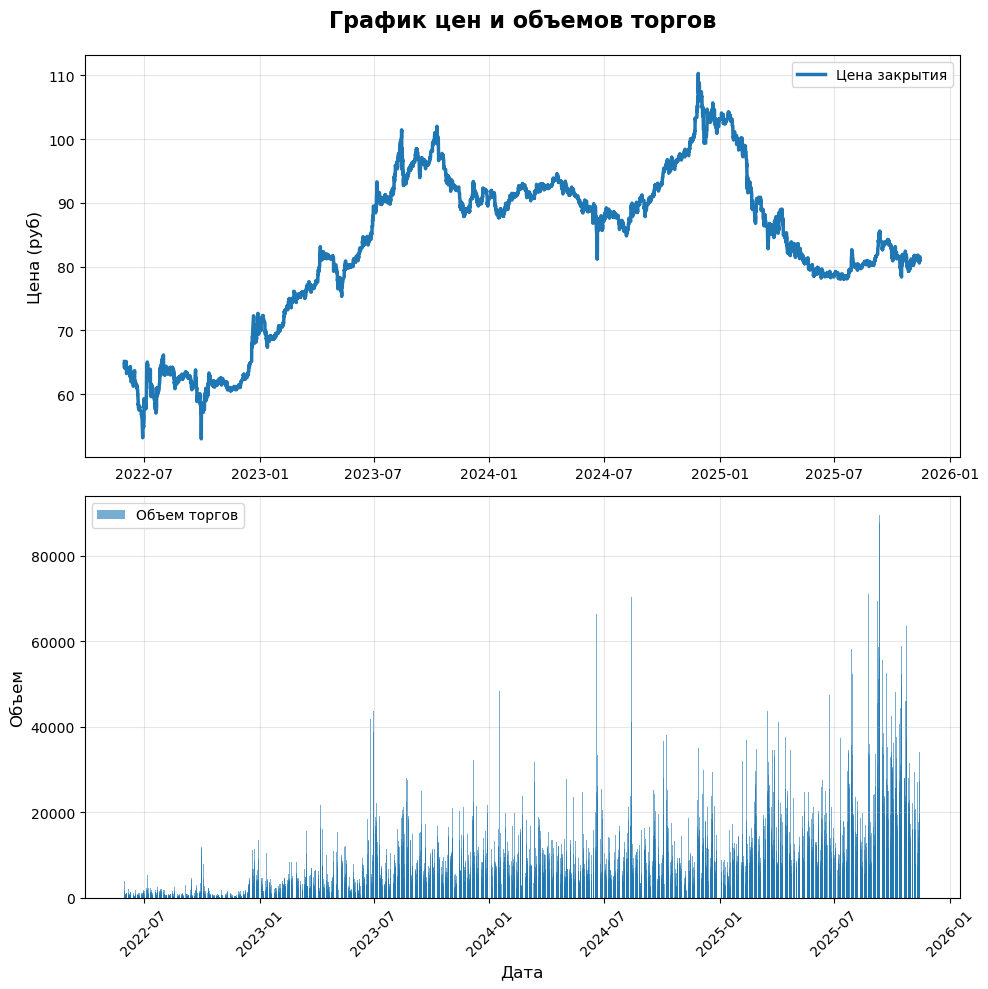

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

df = df.sort_values('begin')

ax1.plot(df['begin'], df['close'], 
        linewidth=2.5, 
        label='Цена закрытия')

ax1.set_title('График цен и объемов торгов', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Цена (руб)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(df['begin'], df['volume'], 
       alpha=0.6,
       label='Объем торгов')

ax2.set_xlabel('Дата', fontsize=12)
ax2.set_ylabel('Объем', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()